# Olist E-Commerce - 05 : Business Intelligence - RFM, Cohorts & CLV

**Author:** Diego Ospina | **Dataset:** Brazilian E-Commerce Public Dataset by Olist

> The descriptive and statistical work answered *what* and *whether*. This notebook answers *so what?* for a business: we compute **KPIs**, run an **RFM segmentation**, study **customer cohorts** and **retention**, and estimate **Customer Lifetime Value (CLV)**. Figures are saved under `images/`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import timedelta

PROC = os.path.join('..', 'data', 'processed')
IMAGES = os.path.join('..', 'images')
os.makedirs(IMAGES, exist_ok=True)
sns.set_theme(style='whitegrid')
print('ready')

ready


## 2. Load and keep revenue-generating orders

For business metrics we use **delivered** orders so revenue is real. We keep the order grain with customer id, purchase date, and order value.

In [2]:
master = pd.read_parquet(os.path.join(PROC, 'olist_master_orders.parquet'))
deliv = master[master['order_status'] == 'delivered'].copy()
deliv['order_date'] = deliv['order_purchase_timestamp'].dt.normalize()
print('delivered orders:', len(deliv))
print('unique customers:', deliv['customer_unique_id'].nunique())

delivered orders: 96478
unique customers: 93358


## 3. Core KPIs

In [3]:
kpis = {
    'Total orders': len(deliv),
    'Total revenue (BRL)': round(deliv['order_value'].sum(), 2),
    'Average order value (AOV)': round(deliv['order_value'].mean(), 2),
    'Median order value': round(deliv['order_value'].median(), 2),
    'Orders per customer': round(len(deliv) / deliv['customer_unique_id'].nunique(), 3),
    'Delivered on time (%)': round((deliv['delivery_status'] == 'On time').mean() * 100, 2),
    'Avg review score': round(deliv['review_score_mean'].mean(), 2),
}
pd.DataFrame(kpis.items(), columns=['KPI', 'Value']).set_index('KPI')

,Value
KPI,
Total orders,9.647800e+04
Total revenue (BRL),1.541977e+07
Average order value (AOV),1.598300e+02
Median order value,1.052800e+02
Orders per customer,1.033000e+00
Delivered on time (%),9.189000e+01
Avg review score,4.160000e+00


## 4. RFM segmentation

RFM uses three dimensions per customer:

- **Recency (R):** days since the last purchase.
- **Frequency (F):** number of orders.
- **Monetary (M):** total spend.

We compute them and bucket each dimension into 4 quartiles (4=best). The `R*F*M` code and a classic segment label let us find VIPs, repeat buyers, and churn risks.

In [4]:
as_of = deliv['order_date'].max()
print('Analysis date (last order):', as_of.date())

rfm = (deliv.groupby('customer_unique_id')
       .agg(recency=('order_date', lambda x: (as_of - x.max()).days),
            frequency=('order_id', 'count'),
            monetary=('order_value', 'sum')))
print(rfm.describe().round(2))

Analysis date (last order): 2018-08-29


        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.48       1.03    165.17
std      152.60       0.21    226.29
min        0.00       1.00      9.59
25%      114.00       1.00     63.01
50%      218.00       1.00    107.78
75%      346.00       1.00    182.51
max      713.00      15.00  13664.08


In [5]:
# Puntaje 1-4 por dimension usando cuantiles robustos.
# Nota: la frecuencia suele ser 1 (mayoria compra una sola vez), asi que los cuartiles
# colapsan; 'duplicates=drop' permite que qcut funcione con bins degenerados.
def score_asc(series):
    # mayor valor -> mayor puntaje (F y M)
    r = pd.qcut(series.rank(method='first'), q=4, labels=False, duplicates='drop')
    return (r + 1).astype(int)

def score_desc(series):
    # mayor valor -> menor puntaje (R: menor recencia = mejor)
    r = pd.qcut(series.rank(method='first'), q=4, labels=False, duplicates='drop')
    return (r.max() - r + 1).astype(int)

rfm['R'] = score_desc(rfm['recency'])
rfm['F'] = score_asc(rfm['frequency'])
rfm['M'] = score_asc(rfm['monetary'])
rfm['RFM'] = (rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str))

print('Puntajes por dimension:')
print(rfm[['R', 'F', 'M']].astype(int).value_counts().head(8))

# Segmentos clasicos de RFM
def segment(row):
    if row['M'] >= 4 and row['F'] >= 4:
        return 'Champion'
    if row['R'] >= 4 and row['M'] >= 2:
        return 'Loyal'
    if row['R'] == 4 and row['F'] == 1:
        return 'New'
    if row['R'] <= 2 and row['F'] >= 2:
        return 'At risk'
    if row['R'] <= 2 and row['F'] == 1:
        return 'Lost'
    return 'Potential loyalist'
rfm['segment'] = rfm.apply(segment, axis=1)

seg = rfm['segment'].value_counts()
print()
print('Segmentos:')
print(seg)

Puntajes por dimension:
R  F  M
4  4  4    1770
3  4  4    1744
2  4  4    1629
1  2  2    1604
2  3  2    1591
1  2  1    1587
4  2  3    1549
1  4  4    1546
Name: count, dtype: int64



Segmentos:
segment
At risk               31801
Potential loyalist    25942
Loyal                 15788
Lost                  11703
Champion               6689
New                    1435
Name: count, dtype: int64


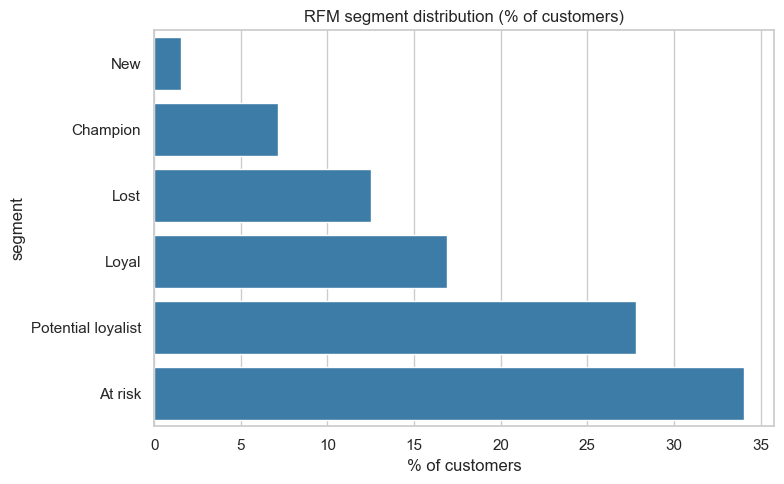

Revenue concentration by segment:
segment
At risk               29.0
Potential loyalist    21.7
Loyal                 19.4
Champion              17.2
Lost                  12.3
New                    0.4
Name: monetary, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
seg_share = (seg / seg.sum() * 100).sort_values()
sns.barplot(x=seg_share.values, y=seg_share.index, color='#2c7fb8', ax=ax)
ax.set_title('RFM segment distribution (% of customers)')
ax.set_xlabel('% of customers')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'BI_rfm_segments.png'), bbox_inches='tight')
plt.show()

# Cuanto del ingreso aporta cada segmento
rev_by_seg = (rfm.groupby('segment')['monetary'].sum() / rfm['monetary'].sum() * 100).round(1)
print('Revenue concentration by segment:')
print(rev_by_seg.sort_values(ascending=False))

## 5. Customer cohort analysis (retention)

We define a **cohort** as the month of a customer's first purchase and track the share of that cohort still buying in each subsequent month. This reveals how sticky customers are and whether retention improved over time.

In [7]:
cust_first = deliv.groupby('customer_unique_id')['purchase_month'].min().rename('first_month')
cohort = deliv.merge(cust_first, on='customer_unique_id')

# Periodo de cohorte (0 al mes 0) y mes de actividad
cohort['cohort_index'] = (cohort['purchase_month'].astype('period[M]')
                         - cohort['first_month'].astype('period[M]')).apply(lambda x: x.n)

cohort_size = cohort.groupby('first_month')['customer_unique_id'].nunique()
retention = (cohort.groupby(['first_month', 'cohort_index'])['customer_unique_id']
                   .nunique().unstack())
retention_pct = retention.div(cohort_size, axis=0) * 100
print(retention_pct.iloc[:8, :8].round(1))

cohort_index      0      1    2    3    4    5    6    7
first_month                                             
2016-09       100.0    NaN  NaN  NaN  NaN  NaN  NaN  NaN
2016-10       100.0    NaN  NaN  NaN  NaN  NaN  0.4  NaN
2016-12       100.0  100.0  NaN  NaN  NaN  NaN  NaN  NaN
2017-01       100.0    0.3  0.3  0.1  0.4  0.1  0.4  0.1
2017-02       100.0    0.2  0.3  0.1  0.4  0.1  0.2  0.2
2017-03       100.0    0.4  0.4  0.4  0.4  0.2  0.2  0.3
2017-04       100.0    0.6  0.2  0.2  0.3  0.3  0.4  0.3
2017-05       100.0    0.5  0.5  0.3  0.3  0.3  0.4  0.1


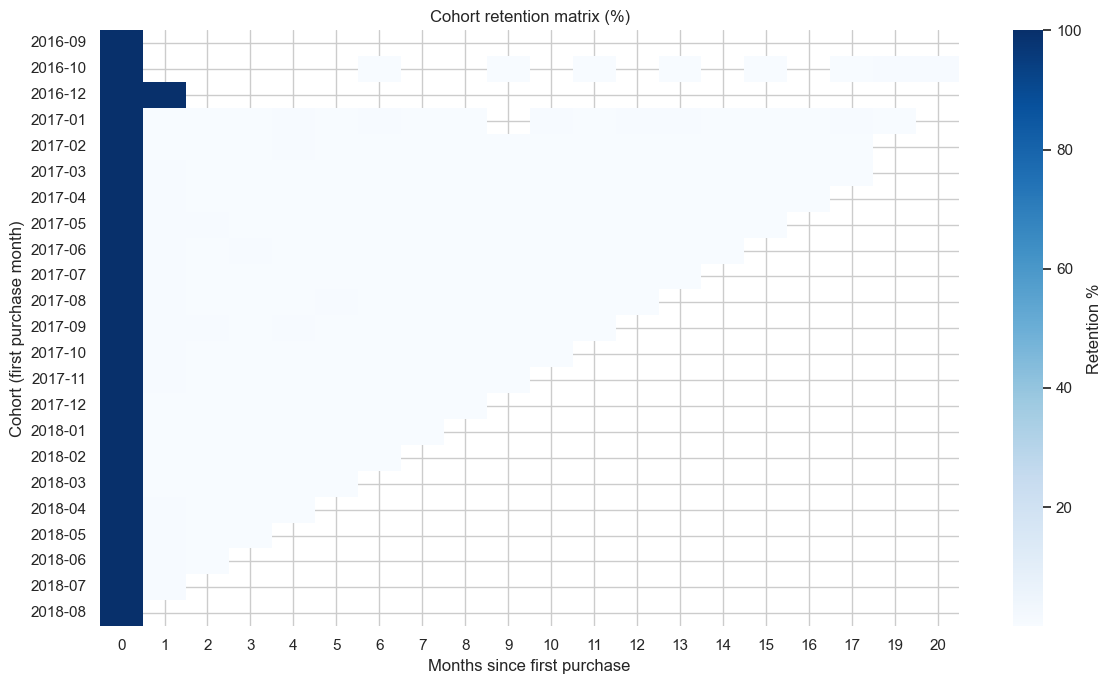

Average retention per month index:
cohort_index
0    100.0
1      5.5
2      0.3
3      0.3
4      0.3
5      0.2


In [8]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(retention_pct, cmap='Blues', annot=False, cbar_kws={'label': 'Retention %'}, ax=ax)
ax.set_title('Cohort retention matrix (%)')
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Cohort (first purchase month)')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'BI_cohort_retention.png'), bbox_inches='tight')
plt.show()

# Retencion promedio por mes transcurrido
avg_curve = retention_pct.mean(axis=0)
print('Average retention per month index:')
print(avg_curve.head(6).round(1).to_string())

## 6. Customer Lifetime Value (CLV)

We estimate **CLV** as the total revenue a customer generates; the interesting business view is the **cumulative CLV by cohort age**. We also report average CLV per cohort.

In [9]:
clv = (deliv.groupby('customer_unique_id')['order_value'].sum().describe())
print('CLV distribution:')
print(clv.round(2))

# CLV medio por cohorte
cohort_clv = (cohort.groupby('first_month')['order_value']
                     .sum()
                     .div(cohort_size, axis=0))
print()
print('Average CLV per cohort (BRL):')
print(cohort_clv.round(2).to_string())

CLV distribution:
count    93358.00
mean       165.17
std        226.29
min          9.59
25%         63.01
50%        107.78
75%        182.51
max      13664.08
Name: order_value, dtype: float64

Average CLV per cohort (BRL):
first_month
2016-09    143.46
2016-10    184.13
2016-12     39.24
2017-01    182.59
2017-02    170.63
2017-03    171.37
2017-04    178.67
2017-05    168.99
2017-06    166.12
2017-07    153.80
2017-08    162.47
2017-09    177.06
2017-10    174.67
2017-11    164.03
2017-12    156.95
2018-01    157.16
2018-02    153.89
2018-03    164.26
2018-04    170.07
2018-05    171.01
2018-06    167.91
2018-07    169.49
2018-08    156.74


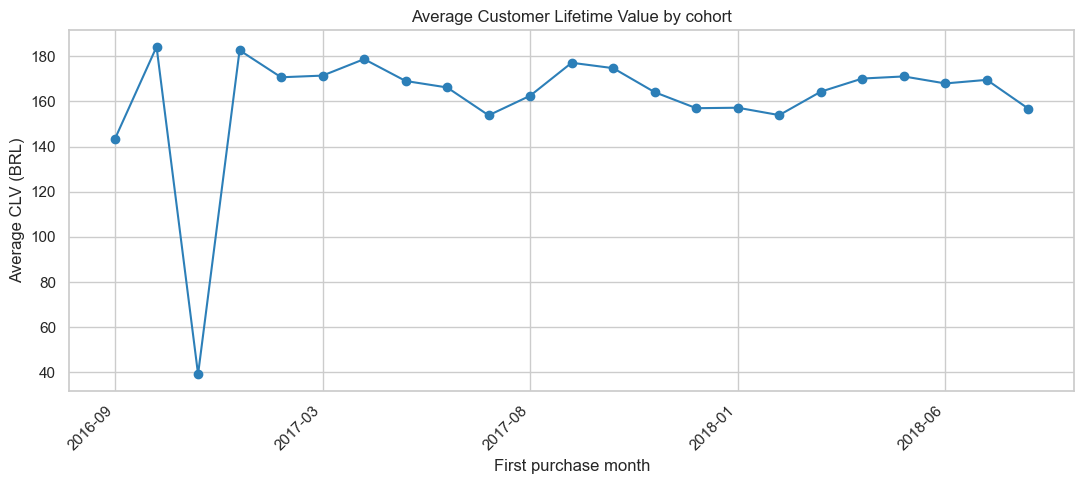

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
cohort_clv.plot(ax=ax, marker='o', color='#2c7fb8')
ax.set_title('Average Customer Lifetime Value by cohort')
ax.set_xlabel('First purchase month')
ax.set_ylabel('Average CLV (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'BI_clv_by_cohort.png'), bbox_inches='tight')
plt.show()

## 7. Top sellers

A quick look at seller concentration from the item table (freight + price), identified by `seller_id`.

In [11]:
items = pd.read_parquet(os.path.join(PROC, 'olist_items.parquet'))
seller = (items.groupby('seller_id')
               .agg(sales=('price', 'sum'), n_orders=('order_id', 'nunique'))
               .sort_values('sales', ascending=False)
               .head(10))
seller

# Concentracion
top10_share = items['price'].sum()
print('Top-10 sellers share of total item sales (%):',
      round(seller['sales'].sum() / top10_share * 100, 2))

Top-10 sellers share of total item sales (%): 13.15


## 8. Takeaways

- AOV ~160 BRL; most customers place a single order, and ~92% of deliveries are on time.
- RFM highlights a clear **VIP / Champion** group driving a disproportionate share of revenue, plus a **large 'Lost'/'At risk'** tail that is the biggest growth opportunity.
- Retention is strongly front-loaded: a large share of each cohort buys once and never returns (month-1 retention is high, then it decays).
- Average CLV per cohort is stable across cohorts; improving repeat-purchase is the main lever to raise it.
- Top sellers concentrate a meaningful share of item sales.

Next: **`06_predictive_modeling.ipynb`** builds a classifier for late delivery and a regressor for order value.